## Imports

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from math import inf
import graphblas as gb
from graphblas import Matrix, Vector, Scalar, dtypes
from graphblas import unary, binary, monoid, semiring
# from graphblas.io import mmread
from pathlib import Path
from scipy.io import mmread
from scipy.sparse import csr_matrix
from graphblas.io import from_scipy_sparse

In [2]:
# def load_graph_from_dense(arr: np.ndarray) -> Matrix:
#     return Matrix.from_dense(arr, missing_value=0)

def load_graph_from_coo(rows: list, cols: list, weights: list, nrows: int | None = None, ncols: int | None = None, dtype=float) -> Matrix:
    return Matrix.from_coo(rows, cols, weights, nrows=nrows, ncols=ncols, dtype=dtype)

In [3]:
# Example graph from seminar
data = [
    [3, 0, 3, 5, 6, 0, 6, 1, 6, 2, 4, 1],
    [0, 1, 2, 2, 2, 3, 3, 4, 4, 5, 5, 6],
    [3, 2, 3, 1, 5, 3, 7, 8, 3, 1, 7, 4],
]

rows, cols, weights = data
example_matrix = load_graph_from_coo(rows, cols, weights, dtype=float)

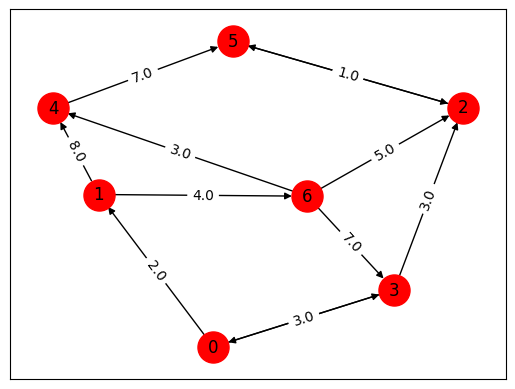

In [4]:
gb.viz.draw(example_matrix)

## SSSP (Single Source Shortest Paths)

In [5]:
def sssp(matrix: Matrix, vertice: int, option: str = "push", density_threshold: float = 0.01):
    nrows = matrix.nrows
    ncols = matrix.ncols
    matrix_dtype = matrix.dtype

    v = Vector(matrix_dtype, ncols)
    v[vertice] << 0

    # Look for the shortest paths
    w = v.dup()

    for i in range(nrows - 1):
        w_old = w.dup()
        # print(w) 
        # print(matrix)

        if option == "push":
            # vxm
            w(binary.min) << w.vxm(matrix, semiring.min_plus)
        elif option == "pull":
            # mxv
            w(binary.min) << matrix.mxv(w, semiring.min_plus)
        elif option == "adaptive":
            density = w.nvals / w.size

            if density < density_threshold:
                # Для разреженного используем push
                w(binary.min) << w.vxm(matrix, semiring.min_plus)
            else:
                # Для плотного используем pull
                w(binary.min) << matrix.mxv(w, semiring.min_plus)
                
        if w.isequal(w_old):
            break

    # Check for negative cycles
    w_new = w.dup()
    w_new(binary.min) << w_new.vxm(matrix, semiring.min_plus)
    if not w_new.isequal(w):
        return None
        
    # For vertices that we cannot reach value is inf
    w(~w.S) << float("inf")

    return w.to_dense().tolist()

In [6]:
# sssp(example_matrix, 0)

## MSSP (Multiple Source Shortest Paths)

In [7]:
def mssp(matrix: Matrix, vertices: list[int]):
    nrows = matrix.nrows

    # Create matrix, row for each vertice
    rows = list(range(len(vertices)))
    cols = vertices.copy()
    weights = [0] * len(vertices)
    mssp_matrix = load_graph_from_coo(rows, cols, weights, ncols=nrows, dtype=float)

    # Look for the shortest paths
    w_matrix = mssp_matrix.dup()
    for i in range(nrows - 1):
        w_old = w_matrix.dup()
        
        w_matrix(binary.min) << w_matrix.mxm(matrix, semiring.min_plus)
        
        if w_matrix.isequal(w_old):
            break

    # Check for negative cycles
    w_new = w_matrix.dup()
    w_new(binary.min) << w_new.mxm(matrix, semiring.min_plus)
    if not w_new.isequal(w_matrix):
        return None
        
    # For vertices that we cannot reach value is inf
    w_matrix(~w_matrix.S) << inf

    w_matrix_arr = w_matrix.to_dense()

    pairs = []

    for idx, el in enumerate(vertices):
        pairs.append((el, w_matrix_arr[idx].tolist()))
        
    return pairs

## Transitive closure

In [8]:
def transitive_closure(matrix: Matrix):
    nrows = matrix.nrows

    boolean_matrix = Matrix(bool, nrows, nrows)

    if matrix.nvals:
            rows_b, cols_b, _ = matrix.to_coo()
            
            boolean_matrix = Matrix.from_coo(
                rows_b, cols_b, [True for _ in range(len(rows_b))],
                nrows=nrows, ncols=nrows
            )

    for i in range(nrows):
        boolean_matrix[i, i] << True

    while True:
        boolean_matrix_old = boolean_matrix.dup()
        boolean_matrix << boolean_matrix.ewise_add(boolean_matrix.mxm(boolean_matrix, semiring.lor_land), monoid.lor)
        if boolean_matrix.isequal(boolean_matrix_old):
            break

    return boolean_matrix

## APSP_FLOYD_WARSHALL

In [9]:
def apsp_floyd_warshall(matrix: Matrix):
    nrows = matrix.nrows
    D = matrix.dup()

    # diagonal of zeros
    for i in range(nrows):
        D[i, i] << 0.0

    # main floyd-warshall
    for k in range(nrows):
        col = D[:, k].new()
        row = D[k, :].new()

        L = load_graph_from_coo(
            col.to_coo()[0],
            np.zeros(col.nvals, dtype=int),
            col.to_coo()[1],
            nrows=nrows, 
            ncols=1, 
            dtype=D.dtype
        )

        R = load_graph_from_coo(
            np.zeros(row.nvals, dtype=int),
            row.to_coo()[0],
            row.to_coo()[1],
            nrows=1, 
            ncols=nrows, 
            dtype=D.dtype
        )

        # calculate candidate
        cand = L.mxm(R, semiring.min_plus).new()

        # update if lesser
        D << D.ewise_add(cand, monoid.min)

    # look for vertices in negative cycle
    diag = Vector(D.dtype, nrows)
    diag << D.diag()
    
    neg_indeces = []
    if diag.nvals:
        idxes, values = diag.to_coo()
        neg_indeces = [int(i) for i, val in zip(idxes, values) if float(val) < 0.0]

    # If we have neg_indeces
    if neg_indeces:
        # create boolean matrix
        boolean_matrix = transitive_closure(matrix)

        # look for all pairs i -> neg cycle -> j
        K = len(neg_indeces)
        
        boolean_matrix_in = Matrix(bool, nrows, K)
        boolean_matrix_out = Matrix(bool, K, nrows)

        for kk, v in enumerate(neg_indeces):
            colv = boolean_matrix[:, v].new()
            idx, _ = colv.to_coo()
            if len(idx):
                boolean_matrix_in = boolean_matrix_in.ewise_add(
                    Matrix.from_coo(
                        idx,
                        np.full(len(idx), kk, dtype=int),
                        np.ones(len(idx), dtype=bool),
                        nrows=nrows, ncols=K
                    ),
                    monoid.lor
                )
            rowv = boolean_matrix[v, :].new()
            jdx, _ = rowv.to_coo()
            if len(jdx):
                boolean_matrix_out = boolean_matrix_out.ewise_add(
                    Matrix.from_coo(
                        np.full(len(jdx), kk, dtype=int),
                        jdx,
                        np.ones(len(jdx), dtype=bool),
                        nrows=K, ncols=nrows
                    ),
                    monoid.lor
                )

        bad_matrix = boolean_matrix_in.mxm(boolean_matrix_out, semiring.lor_land).new()
        
        bi, bj, _ = bad_matrix.to_coo()
        for i, j in zip(bi, bj):
            D[int(i), int(j)] << float('inf')

    for i in range(nrows):
        D[i, i] << 0.0

    pairs = []

    D(~D.S) << inf
    D_arr = D.to_dense()

    for idx in range(nrows):
        pairs.append((idx, D_arr[idx].tolist()))

    return pairs

## Tests

### General test function

In [10]:
def test_algorithm(cases_dct, option: str):
    for case_name, case in cases_dct.items():
        print(f"Check case: [{case_name}]")

        current_matrix = load_graph_from_coo(
            case["rows"],
            case["cols"],
            case["weights"],
            case.get("nrows", None),
            case.get("ncols", None)
        )

        if option == "apsp_floyd_warshall":
            ans = apsp_floyd_warshall(current_matrix)
        elif option == "mssp":
            ans = mssp(current_matrix, case["vertices"])
        elif option == "sssp":
            ans = sssp(current_matrix, case["vertice"])
        elif option == "transitive_closure":
            ans = transitive_closure(current_matrix)
            ans(~ans.S) << False
            ans = ans.to_dense().tolist()
        else:
            raise ValueError("Option for test should be in this list = [apsp_floyd_warshall, mssp, sssp]!")
            
        if ans == case["ans"]:
            print("Case successfully solved using apsp function!")
        else:
            print("Case not solved!")
            break

    print("All tests were solved!")

### Test SSSP

In [11]:
cases_dct_sssp = {
        "simple_graph": {
            "rows": [0, 0, 1, 2],  
            "cols": [1, 2, 2, 3],  
            "weights": [1, 4, 2, 1],
            "vertice": 0,
            "nrows": 4,
            "ncols": 4,
            "ans": [0, 1, 3, 4]  
        },
        "negative_edges_without_neg_cycle": {
            "rows": [0, 0, 1, 2],
            "cols": [1, 2, 2, 3],
            "weights": [3, 7, -2, 1],
            "nrows": 4,
            "ncols": 4,
            "vertice": 0,
            "ans": [0, 3, 1, 2],
        },
        "negative_cycle": {
            "rows": [0, 1, 2],
            "cols": [1, 2, 0],
            "weights": [1, 1, -3],
            "nrows": 3,
            "ncols": 3,
            "vertice": 0,
            "ans": None
        },
        "graph_with_one_vertice": {
            "rows": [],
            "cols": [],
            "weights": [],
            "nrows": 1,
            "ncols": 1,
            "vertice": 0,
            "ans": [0]
        },
        "several_paths_to_choose_min": {
            "rows": [0, 0, 0, 1, 2],
            "cols": [1, 2, 3, 3, 3],
            "weights": [1, 2, 10, 3, 1],
            "nrows": 4,
            "ncols": 4,
            "vertice": 0,
            "ans": [0, 1, 2, 3],
        }
    }

test_algorithm(cases_dct_sssp, "sssp")

Check case: [simple_graph]
Case successfully solved using apsp function!
Check case: [negative_edges_without_neg_cycle]
Case successfully solved using apsp function!
Check case: [negative_cycle]
Case successfully solved using apsp function!
Check case: [graph_with_one_vertice]
Case successfully solved using apsp function!
Check case: [several_paths_to_choose_min]
Case successfully solved using apsp function!
All tests were solved!


### Test MSSP

In [12]:
cases_dct_mssp = {
        "mssp_simple": {
            "rows": [0, 0, 1, 2],
            "cols": [1, 2, 2, 3],
            "weights": [1, 4, 2, 1],
            "nrows": 4,
            "ncols": 4,
            "vertices": [0, 2],
            "ans": [
                (0, [0, 1, 3, 4]),
                (2, [float("inf"), float("inf"), 0, 1]),
            ]
        },
        "mssp_negative_edges": {
            "rows": [0, 0, 1, 2],
            "cols": [1, 2, 2, 3],
            "weights": [3, 7, -2, 1],
            "nrows": 4,
            "ncols": 4,
            "vertices": [0, 1],
            "ans": [
                (0, [0, 3, 1, 2]),
                (1, [float("inf"), 0, -2, -1]),
            ]
        },
        "mssp_negative_cycle": {
            "rows": [0, 1, 2],
            "cols": [1, 2, 0],
            "weights": [1, 1, -3],
            "nrows": 3,
            "ncols": 3,
            "vertices": [0, 1],
            "ans": None
        },
        "mssp_single_vertex": {
            "rows": [],
            "cols": [],
            "weights": [],
            "nrows": 1,
            "ncols": 1,
            "vertices": [0],
            "ans": [
                (0, [0]),
            ]
        },
        "mssp_unreachable": {
            "rows": [0, 1],
            "cols": [1, 2],
            "weights": [5, 3],
            "nrows": 4,
            "ncols": 4,
            "vertices": [0, 2],
            "ans": [
                (0, [0, 5, 8, float("inf")]),
                (2, [float("inf"), float("inf"), 0, float("inf")]),
            ]
        },
        "mssp_all_vertices": {
            "rows": [0, 0, 0, 1, 2],
            "cols": [1, 2, 3, 3, 3],
            "weights": [1, 2, 10, 3, 1],
            "nrows": 4,
            "ncols": 4,
            "vertices": [0, 1, 2, 3],
            "ans": [
                (0, [0, 1, 2, 3]),
                (1, [float("inf"), 0, float("inf"), 3]),
                (2, [float("inf"), float("inf"), 0, 1]),
                (3, [float("inf"), float("inf"), float("inf"), 0]),
            ]
        },
    }

test_algorithm(cases_dct_mssp, "mssp")

Check case: [mssp_simple]
Case successfully solved using apsp function!
Check case: [mssp_negative_edges]
Case successfully solved using apsp function!
Check case: [mssp_negative_cycle]
Case successfully solved using apsp function!
Check case: [mssp_single_vertex]
Case successfully solved using apsp function!
Check case: [mssp_unreachable]
Case successfully solved using apsp function!
Check case: [mssp_all_vertices]
Case successfully solved using apsp function!
All tests were solved!


### Test APSP_FLOYD_WARSHALL

In [13]:
cases_dct_apsp_floyd_warshall = {
        "apsp_simple": {
            "rows": [0, 0, 1, 2],
            "cols": [1, 2, 2, 3],
            "weights": [1.0, 4.0, 2.0, 1.0],
            "nrows": 4,
            "ncols": 4,
            "ans": [
                (0, [0.0, 1.0, 3.0, 4.0]),
                (1, [float("inf"), 0.0, 2.0, 3.0]),
                (2, [float("inf"), float("inf"), 0.0, 1.0]),
                (3, [float("inf"), float("inf"), float("inf"), 0.0]),
            ]
        },
        "apsp_negative_weights": {
            "rows": [0, 1, 2, 2],
            "cols": [1, 2, 0, 3],
            "weights": [1.0, -2.0, 1.0, 1.0],
            "nrows": 4,
            "ncols": 4,
            "ans": [
                (0, [0.0, 1.0, -1.0, 0.0]),
                (1, [-1.0, 0.0, -2.0, -1.0]),
                (2, [1.0, 2.0, 0.0, 1.0]),
                (3, [float("inf"), float("inf"), float("inf"), 0.0]),
            ]
        },
        "apsp_negative_cycle": {
            "rows": [0, 1, 2, 0],
            "cols": [1, 2, 0, 3],
            "weights": [1.0, 1.0, -3.0, 5.0],
            "nrows": 4,
            "ncols": 4,
            "ans": [
                (0, [0.0, float("inf"), float("inf"), float("inf")]),
                (1, [float("inf"), 0.0, float("inf"), float("inf")]),
                (2, [float("inf"), float("inf"), 0.0, float("inf")]),
                (3, [float("inf"), float("inf"), float("inf"), 0.0]),
            ]
        },
        "apsp_disconnected": {
            "rows": [0, 2],
            "cols": [1, 3],
            "weights": [2.0, 3.0],
            "nrows": 4,
            "ncols": 4,
            "ans": [
                (0, [0.0, 2.0, float("inf"), float("inf")]),
                (1, [float("inf"), 0.0, float("inf"), float("inf")]),
                (2, [float("inf"), float("inf"), 0.0, 3.0]),
                (3, [float("inf"), float("inf"), float("inf"), 0.0]),
            ]
        },
        "apsp_single_node": {
            "rows": [],
            "cols": [],
            "weights": [],
            "nrows": 1,
            "ncols": 1,
            "ans": [
                (0, [0.0]),
            ]
        },
    }

test_algorithm(cases_dct_apsp_floyd_warshall, "apsp_floyd_warshall")

Check case: [apsp_simple]
Case successfully solved using apsp function!
Check case: [apsp_negative_weights]
Case successfully solved using apsp function!
Check case: [apsp_negative_cycle]
Case successfully solved using apsp function!
Check case: [apsp_disconnected]
Case successfully solved using apsp function!
Check case: [apsp_single_node]
Case successfully solved using apsp function!
All tests were solved!


### Test for transitive closure

In [14]:
cases_dct_transitive_closure = {
        "tc_simple": {
            "rows": [0, 1, 2],
            "cols": [1, 2, 3],
            "weights": [1, 1, 1],
            "nrows": 4,
            "ncols": 4,
            "ans": [[True,  True,  True,  True ],
                    [False, True,  True,  True ],
                    [False, False, True,  True ],
                    [False, False, False, True ]]
            },
        "tc_cycle": {
            "rows": [0, 1, 2],
            "cols": [1, 2, 0],
            "weights": [1, 1, 1],
            "nrows": 3,
            "ncols": 3,
            "ans": [[True, True, True],
                [True, True, True],
                [True, True, True],]
            },
        "tc_disconnected": {
            "rows": [0, 2],
            "cols": [1, 3],
            "weights": [1, 1],
            "nrows": 4,
            "ncols": 4,
            "ans": [[True,  True,  False, False],
                [False, True,  False, False],
                [False, False, True,  True ],
                [False, False, False, True ]]
            },
        "tc_already_complete": {
            "rows": [0, 0, 1, 1, 2, 2],
            "cols": [1, 2, 0, 2, 0, 1],
            "weights": [1, 1, 1, 1, 1, 1],
            "nrows": 3,
            "ncols": 3,
            "ans": [[True, True, True],
                [True, True, True],
                [True, True, True]]
            },
    }

test_algorithm(cases_dct_transitive_closure, "transitive_closure")

Check case: [tc_simple]
Case successfully solved using apsp function!
Check case: [tc_cycle]
Case successfully solved using apsp function!
Check case: [tc_disconnected]
Case successfully solved using apsp function!
Check case: [tc_already_complete]
Case successfully solved using apsp function!
All tests were solved!


## Исследование полученных реализаций на больших графах

In [15]:
files_with_graphs = []

for file in Path("./new_graph_data").iterdir():
    if file.is_file():
        if file.suffix == ".mtx":
            files_with_graphs.append(file)

In [16]:
matrices_graphs = []

for filepath in files_with_graphs:
    current_sparse_matrix = mmread(filepath)
    current_A = from_scipy_sparse(csr_matrix(current_sparse_matrix))

    if current_A.nrows != current_A.ncols:
        print(f"Skipping {filepath}: not square ({current_A.nrows}x{current_A.ncols})")
        continue

    matrices_graphs.append(current_A)

Skipping new_graph_data/illc1033.mtx: not square (1033x320)


Оценим результаты работы алгоритмов на графах с SuiteSparse Matrix Collection.

In [17]:
algorithms = {
    # "sssp": sssp,
    "mssp": mssp,
    "apsp_floyd_warshall": apsp_floyd_warshall,
}

# Для сохранения результатов
results_dct = {f"Time in sec: {name_algorithm}": [] for name_algorithm in algorithms.keys()}

# Также будем хранить информацию о конкретном графе и кол-ве стартовых вершин в msbfs 
results_dct["Кол-во строк в матрице смежности"] = []
results_dct["Кол-во колонок в матрице смежности"] = []
results_dct["Непустых значений (не 0)"] = []
# results_dct["Разреженность"] = []
results_dct["Средняя степень вершины"] = []

for current_matrix in matrices_graphs:
    # Записываем информацию он конкретном графе
    results_dct["Кол-во строк в матрице смежности"].append(current_matrix.nrows)
    # print(current_matrix.nrows)
    results_dct["Кол-во колонок в матрице смежности"].append(current_matrix.ncols)
    results_dct["Непустых значений (не 0)"].append(current_matrix.nvals)
    # results_dct["Разреженность"].append(1 - (current_matrix.nvals) / (current_matrix.nrows * current_matrix.ncols))
    results_dct["Средняя степень вершины"].append(current_matrix.nvals / current_matrix.nrows)

    for algo_name, algorithm_function in algorithms.items():
        # print(algo_name)
        # Засекаем время в начале
        start_time = time.perf_counter()
        if algo_name == "apsp_floyd_warshall":
            # Прогоняем наш алгоритм на графе
            _ = algorithm_function(current_matrix)
        elif algo_name == "mssp":
            _ = algorithm_function(current_matrix, list(range(current_matrix.nrows)))
        else:
            continue

        # Считаем время в конце
        end_time = time.perf_counter()

        total_time = end_time - start_time
    
        results_dct[f"Time in sec: {algo_name}"].append(total_time)

In [18]:
# Смотрим на результаты прогона наших алгоритмов по графам
results_df = pd.DataFrame(results_dct)
results_df.head(2)

,Time in sec: mssp,Time in sec: apsp_floyd_warshall,Кол-во строк в матрице смежности,Кол-во колонок в матрице смежности,Непустых значений (не 0),Средняя степень вершины
0,0.020916,0.097143,131,131,536,4.091603
1,0.003822,0.035263,187,187,1491,7.973262


### Сравним скорость работы алгоритмов MSSP и APSP Floyd-Warshall для задачи поиска кратчайших расстояний от любой вершины до любой

In [19]:
def plot_results_suitesparse(df: pd.DataFrame, bin_column: str, col: str, num_bins=3):    
    # Делим на 3 бина по средней степени
    df["bin"] = pd.cut(df[bin_column], bins=num_bins)
    bins = sorted(df["bin"].unique())
    
    fig, axes = plt.subplots(1, len(bins), figsize=(5 * len(bins), 5), sharey=False)
    if len(bins) == 1:
        axes = [axes]
    
    for ax, bin_label in zip(axes, bins):
        group = df[df["bin"] == bin_label]
        
        # Сортируем по числу вершин для корректного линейного графика
        group = group.sort_values(col)
        
        ax.plot(group[col],
                group["Time in sec: mssp"],
                "o-", label="mssp", alpha=0.8)
        ax.plot(group[col],
                group["Time in sec: apsp_floyd_warshall"],
                "s-", label="floyd-warshall", alpha=0.8)
        
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel(col)
        ax.set_ylabel("Время (сек)")
        ax.set_title(f"{bin_column}: {bin_label}")
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.suptitle(f"Зависимость времени от {col}\n (по диапазонам {bin_column})")
    plt.tight_layout()
    plt.show()

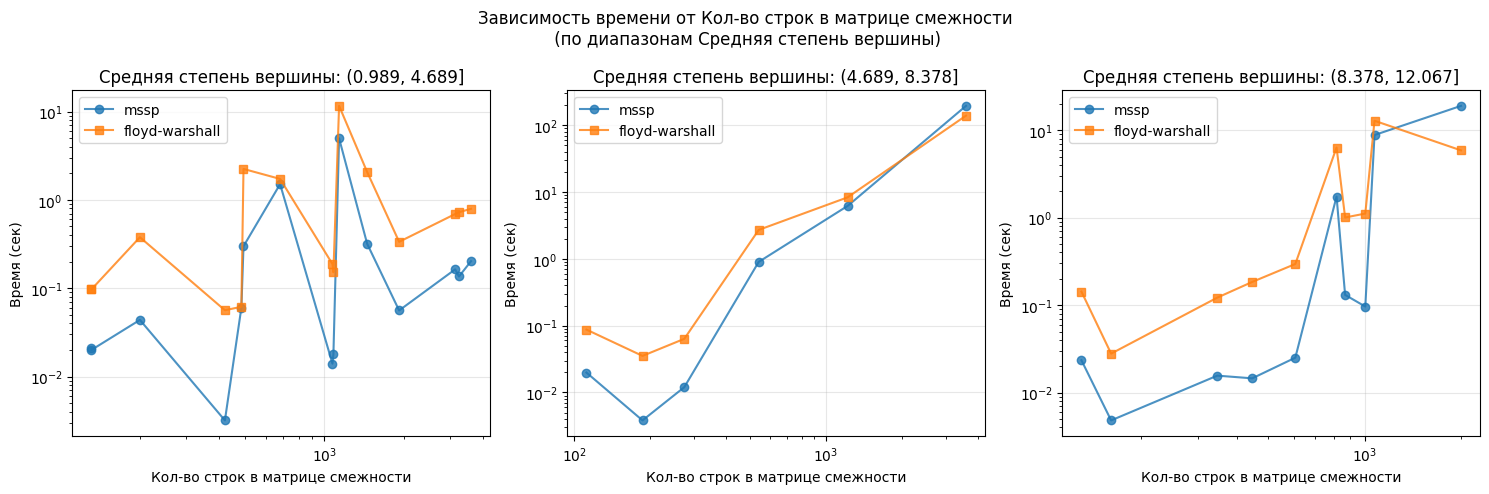

In [20]:
plot_results_suitesparse(results_df, "Средняя степень вершины", "Кол-во строк в матрице смежности")

- MSSP стабильно опережает Floyd-Warshall по скорости независимо от размера графа.

- Время работы обоих алгоритмов закономерно растёт по мере увеличения числа вершин.
  
- При фиксированном числе вершин более плотные графы (с высокой средней степенью) требуют больше времени для обоих алгоритмов.

Возможные причины, по котором APSP Floyd Warshall медленнее MSSP:

1. Floyd-Warshall делает N итераций в цикле, много раз проделывает операции to_coo и from_coo, пересоздает временные матрицы L и R. MSSP проделывает одну операцию mxm за итерацию.
   
2. MSSP останавливается, после того как расстояния перестают меняться, в то время как Floyd-Warshall всегда делает N итераций.

### Сравним результаты алгоритмов MSSP и SSSP для разного кол-ва стартовых вершин на графах с SuiteSparse.

In [21]:
new_algorithms = {
    "sssp": sssp,
    "mssp": mssp,
}

mssp_sssp_results_dct = {f"Time in sec: {name_algorithm}": [] for name_algorithm in new_algorithms.keys()}

mssp_sssp_results_dct["Кол-во строк в матрице смежности"] = []
mssp_sssp_results_dct["Кол-во колонок в матрице смежности"] = []
mssp_sssp_results_dct["Непустых значений (не 0)"] = []
mssp_sssp_results_dct["Средняя степень вершины"] = []
mssp_sssp_results_dct["Кол-во стартовых вершин"] = []

for current_matrix in matrices_graphs:
    starting_vertices_lst = list(range(current_matrix.nrows))
    if current_matrix.nrows > 1000:
        period = 500
    else:
        period = 100
    for idx in range(1, min(1000, len(starting_vertices_lst)), period):
        mssp_sssp_results_dct["Кол-во строк в матрице смежности"].append(current_matrix.nrows)
        mssp_sssp_results_dct["Кол-во колонок в матрице смежности"].append(current_matrix.ncols)
        mssp_sssp_results_dct["Непустых значений (не 0)"].append(current_matrix.nvals)
        mssp_sssp_results_dct["Средняя степень вершины"].append(current_matrix.nvals / current_matrix.nrows)
        
        current_vertices = starting_vertices_lst[:idx]

        mssp_sssp_results_dct["Кол-во стартовых вершин"].append(len(current_vertices))

        for algo_name, algorithm_function in new_algorithms.items():          
            # Засекаем время в начале
            start_time = time.perf_counter()
            
            if algo_name == "sssp":
                # Прогоняем наш алгоритм на графе
                for current_ver in current_vertices:
                    algorithm_function(current_matrix, current_ver)
            elif algo_name == "mssp":
                _ = algorithm_function(current_matrix, current_vertices)
            else:
                continue
    
            # Считаем время в конце
            end_time = time.perf_counter()
    
            total_time = end_time - start_time
        
            mssp_sssp_results_dct[f"Time in sec: {algo_name}"].append(total_time)

In [22]:
def plot_dependence(df: pd.DataFrame, group_col: str, title: str):
    grouped = df.groupby(group_col).mean()
    
    plt.figure(figsize=(10, 5))
    plt.plot(grouped.index, grouped["Time in sec: sssp"], marker="o", label="sssp")
    plt.plot(grouped.index, grouped["Time in sec: mssp"], marker="s", label="mssp")
    plt.xlabel(group_col)
    plt.ylabel("Время в сек")
    plt.xscale("log")
    plt.yscale("log")
    plt.title(f"Зависимость времени от {group_col} ({title})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

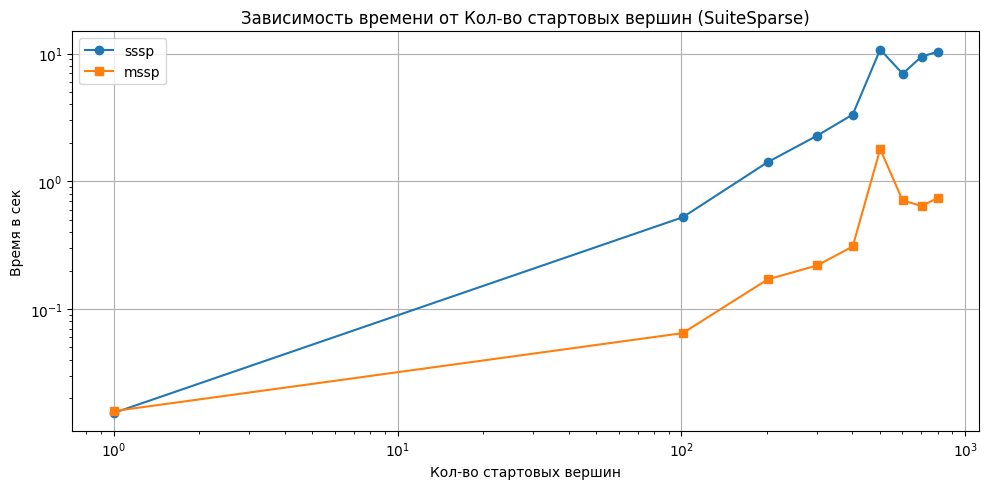

In [23]:
mssp_sssp_results_df = pd.DataFrame(mssp_sssp_results_dct)
plot_dependence(mssp_sssp_results_df, "Кол-во стартовых вершин", "SuiteSparse")

- Время работы алгоритмов MSSP и SSSP растет с увеличением числа стартовых вершин.

- MSSP быстрее SSSP при любом количестве стартовых вершин, а с ростом их числа разрыв в производительности увеличивается.

### Сравним работу SSSP и MSSP на случайных сгенерированных графах

In [24]:
def generate_graph_randomly(
    n_vertices: int,
    p_of_edge: float,
    random_seed: int = 42
) -> Matrix:
    # Задаем генератор случайных чисел
    rng = np.random.default_rng(random_seed)

    # Выбираем индексы
    row_idx, col_idx = np.indices((n_vertices, n_vertices))

    row_idx = row_idx.flatten()
    col_idx = col_idx.flatten()

    # Создаем маску
    mask = (rng.random(len(row_idx)) <= p_of_edge) & (row_idx != col_idx)

    # Оставляем только те пары вершин, которые прошли маску
    src = row_idx[mask]
    dst = col_idx[mask]

    # Непустые значения = 1
    vals = np.ones(len(src), dtype=int)
    
    return Matrix.from_coo(src, dst, vals, nrows=n_vertices, ncols=n_vertices)

Запустим эксперименты.

In [25]:
all_algorithms = {
    "sssp": sssp,
    "mssp": mssp,
    "apsp_floyd_warshall": apsp_floyd_warshall,
}

# Сетка значений кол-ва стартовых вершин
starting_vertices_grid = [
    np.arange(0, i).tolist() for i in [5, 10, 10 ** 2, 10 ** 3]
]

# Для сохранения результатов
results_random_graphs_dct = {f"Time in sec: {name_algorithm}": [] for name_algorithm in all_algorithms.keys()}

results_random_graphs_dct["Кол-во строк в матрице смежности"] = []
results_random_graphs_dct["Кол-во колонок в матрице смежности"] = []
results_random_graphs_dct["Непустых значений (не 0)"] = []
results_random_graphs_dct["Кол-во стартовых вершин"] = []
results_random_graphs_dct["Разреженность"] = []

# Кол-во экспериментов
n_runs = 15

# Задаем изначальный seed
current_seed = 1

# Сетка для значений кол-ва вершин
n_vertices_grid = [10 ** i for i in range(1, 4)]

# Сетка для значений показателя разреженности
p_of_edge_grid = [0.001, 0.005, 0.01, 0.05] # was also 0.1

for current_n_vertices in n_vertices_grid:
    for current_start_vertices in starting_vertices_grid:
        # Стартовых вершин не может быть больше, чем вершин конкретного графа
        if max(current_start_vertices) >= current_n_vertices:
            continue
        for current_p_edge in p_of_edge_grid:
            for run in range(1, n_runs + 1):
                current_matrix = generate_graph_randomly(current_n_vertices, current_p_edge, random_seed=current_seed)
                results_random_graphs_dct["Кол-во строк в матрице смежности"].append(current_matrix.nrows)
                results_random_graphs_dct["Кол-во колонок в матрице смежности"].append(current_matrix.ncols)
                results_random_graphs_dct["Непустых значений (не 0)"].append(current_matrix.nvals)
                results_random_graphs_dct["Кол-во стартовых вершин"].append(len(current_start_vertices))
                # results_random_graphs_dct["Разреженность"].append(1 - (current_matrix.nvals) / (current_matrix.nrows * current_matrix.ncols))
                results_random_graphs_dct["Разреженность"].append(1 - current_p_edge)

                # Идем по алгоритмам
                for algorithm_name, algorithm_function in all_algorithms.items():
                    # Засекаем время в начале
                    start_time = time.perf_counter()

                    # print(algorithm_name)

                    if algorithm_name == "mssp":
                        # Прогоняем наш алгоритм на графе
                        _ = algorithm_function(current_matrix, current_start_vertices)
                    elif algorithm_name == "sssp":
                        for current_ver in current_start_vertices:
                            _ = algorithm_function(current_matrix, current_ver)
                    elif algorithm_name == "apsp_floyd_warshall":
                        _ = algorithm_function(current_matrix)
                        
        
                    # Считаем время в конце
                    end_time = time.perf_counter()
            
                    total_time = end_time - start_time
            
                    results_random_graphs_dct[f"Time in sec: {algorithm_name}"].append(total_time)

                # Обновляем seed
                current_seed += 1

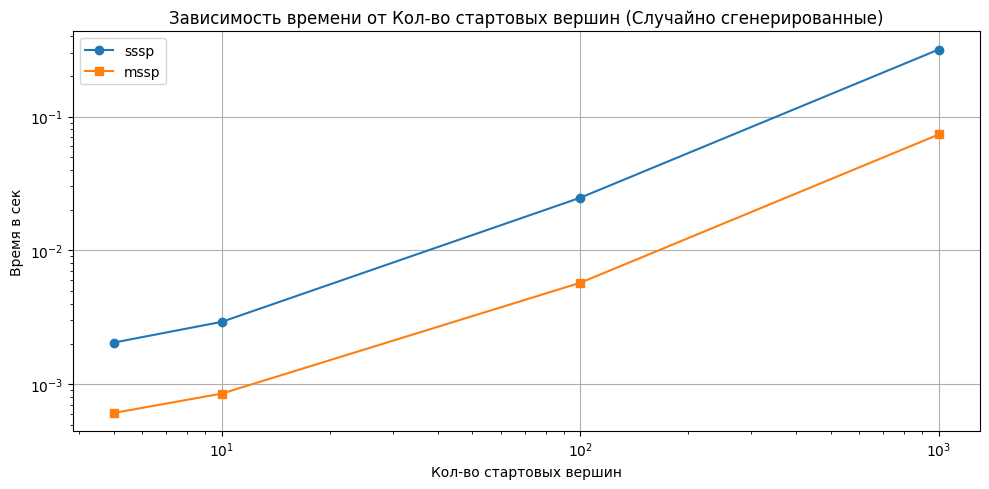

In [26]:
results_random_graphs_df = pd.DataFrame(results_random_graphs_dct)
plot_dependence(results_random_graphs_df, "Кол-во стартовых вершин", "Случайно сгенерированные")

- На случайных графах время работы алгоритмов MSSP и SSSP также растет с увеличением числа стартовых вершин, как и на графах SuiteSparse.
  
- MSSP все также быстрее.

### Теперь сравним на случайных графах MSSP и APSP Floyd-Warshall

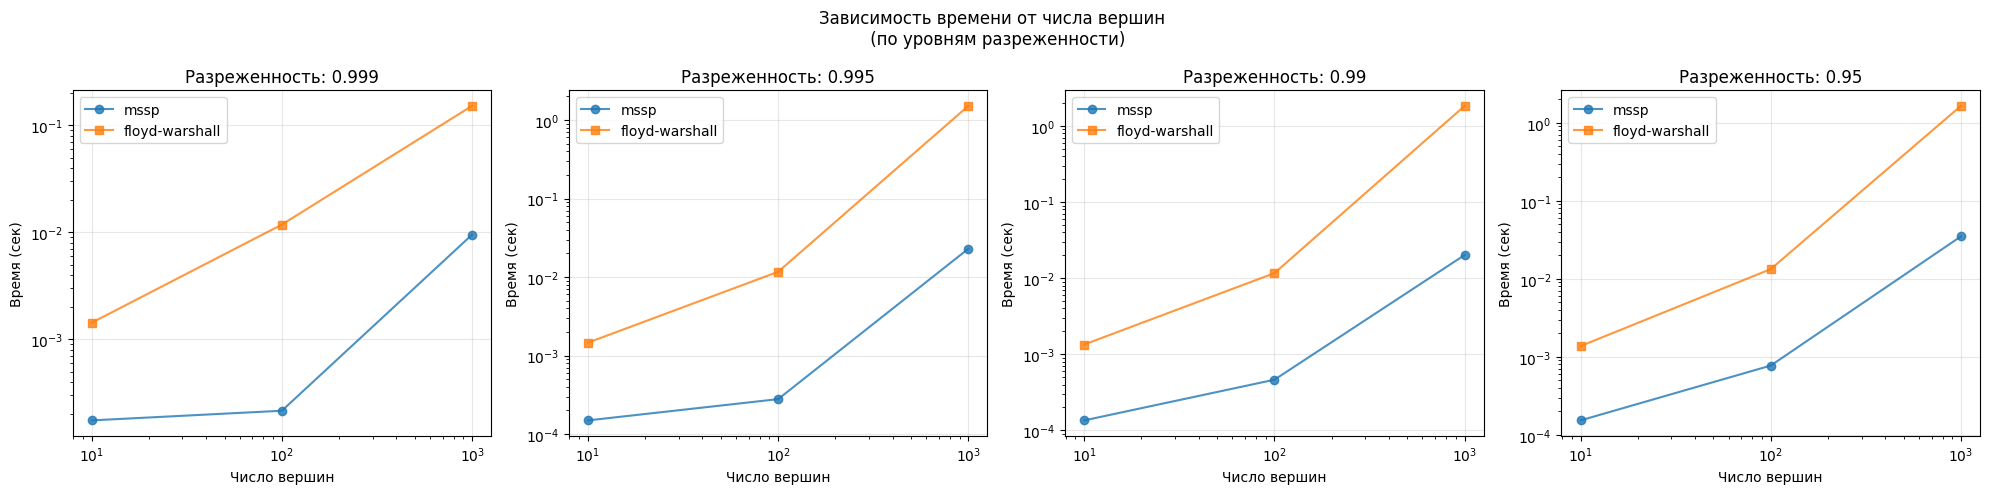

In [27]:
fig, axes = plt.subplots(1, len(p_of_edge_grid), figsize=(5 * len(p_of_edge_grid), 5), sharey=False)

for ax, p in zip(axes, p_of_edge_grid):
    group = results_random_graphs_df[results_random_graphs_df["Разреженность"] == 1 - p]
    group = group.groupby("Кол-во строк в матрице смежности").mean(numeric_only=True).reset_index()
    group = group.sort_values("Кол-во строк в матрице смежности")

    ax.plot(group["Кол-во строк в матрице смежности"],
            group["Time in sec: mssp"], "o-", label="mssp", alpha=0.8)
    ax.plot(group["Кол-во строк в матрице смежности"],
            group["Time in sec: apsp_floyd_warshall"], "s-", label="floyd-warshall", alpha=0.8)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Число вершин")
    ax.set_ylabel("Время (сек)")
    ax.set_title(f"Разреженность: {1 - p}")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Зависимость времени от числа вершин \n (по уровням разреженности)")
plt.tight_layout()
plt.show()

- Оба алгоритма демонстрируют рост времени выполнения с увеличением числа вершин.

- Floyd-Warshall уступает MSSP по скорости вне зависимости от размера графа.

## Оценим эффект от push/pull оптимизаций для алгоритма SSSP

In [32]:
from functools import partial

sssp_algorithms = {
    "sssp_push": partial(sssp, option="push"),
    "sssp_pull": partial(sssp, option="pull"),
    "sssp_adaptive (threshold = 0.15)": partial(sssp, option="adaptive", density_threshold=0.15)
}

sssp_algorithms_dct = {f"Time in sec: {name_algorithm}": [] for name_algorithm in sssp_algorithms.keys()}

sssp_algorithms_dct["Кол-во строк в матрице смежности"] = []
sssp_algorithms_dct["Кол-во колонок в матрице смежности"] = []
sssp_algorithms_dct["Непустых значений (не 0)"] = []
sssp_algorithms_dct["Кол-во стартовых вершин"] = []
sssp_algorithms_dct["Разреженность"] = []

n_vertices_grid = [10 ** i for i in range(1, 5)]

for current_n_vertices in n_vertices_grid:
    for current_start_vertices in starting_vertices_grid:
        # Стартовых вершин не может быть больше, чем вершин конкретного графа
        if max(current_start_vertices) >= current_n_vertices:
            continue
        for current_p_edge in p_of_edge_grid:
            for run in range(1, n_runs + 1):
                current_matrix = generate_graph_randomly(current_n_vertices, current_p_edge, random_seed=current_seed)
                sssp_algorithms_dct["Кол-во строк в матрице смежности"].append(current_matrix.nrows)
                sssp_algorithms_dct["Кол-во колонок в матрице смежности"].append(current_matrix.ncols)
                sssp_algorithms_dct["Непустых значений (не 0)"].append(current_matrix.nvals)
                sssp_algorithms_dct["Кол-во стартовых вершин"].append(len(current_start_vertices))
                sssp_algorithms_dct["Разреженность"].append(1 - current_p_edge)

                # Идем по алгоритмам
                for algorithm_name, algorithm_function in sssp_algorithms.items():
                    # Засекаем время в начале
                    start_time = time.perf_counter()

                    _ = algorithm_function(current_matrix, current_start_vertices)
                
                    # Считаем время в конце
                    end_time = time.perf_counter()
            
                    total_time = end_time - start_time
            
                    sssp_algorithms_dct[f"Time in sec: {algorithm_name}"].append(total_time)

                # Обновляем seed
                current_seed += 1

In [29]:
# mssp_algorithms_dct

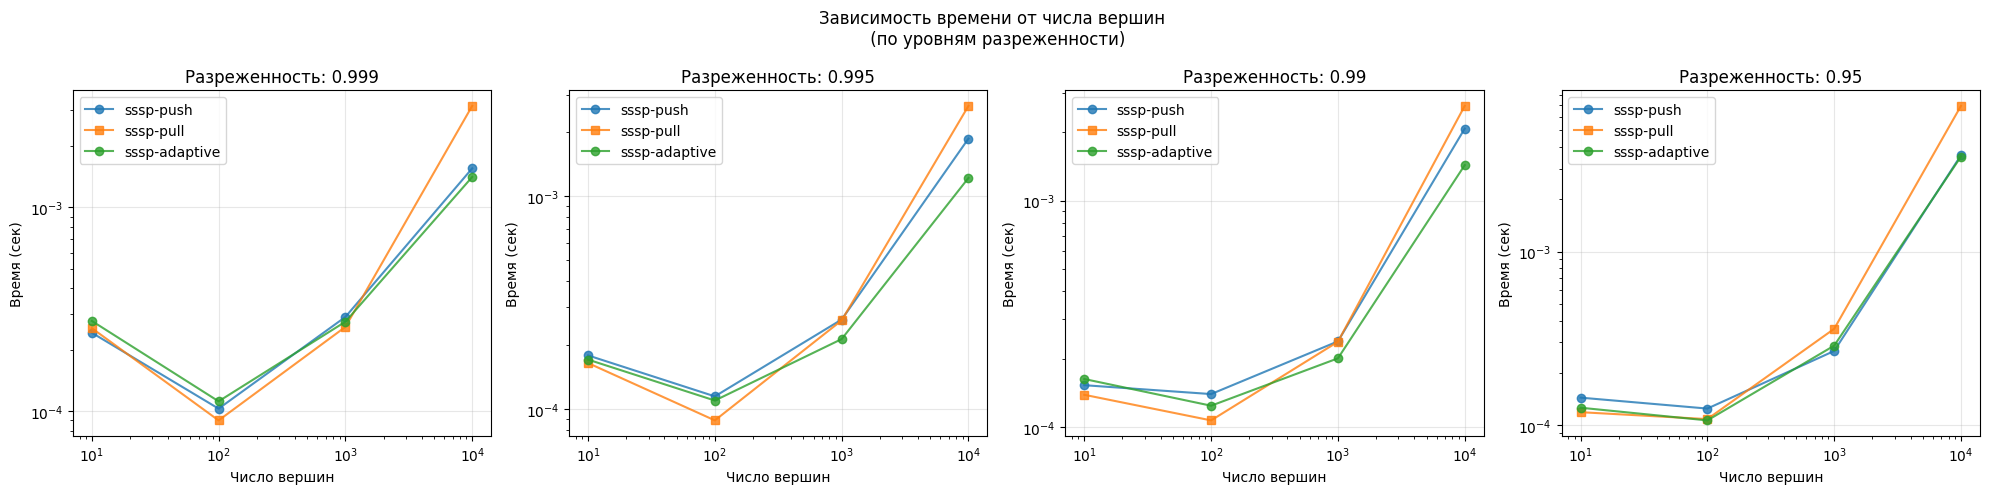

In [33]:
sssp_algorithms_df = pd.DataFrame(sssp_algorithms_dct)

fig, axes = plt.subplots(1, len(p_of_edge_grid), figsize=(5 * len(p_of_edge_grid), 5), sharey=False)

for ax, p in zip(axes, p_of_edge_grid):
    group = sssp_algorithms_df[sssp_algorithms_df["Разреженность"] == 1 - p]
    group = group.groupby("Кол-во строк в матрице смежности").mean(numeric_only=True).reset_index()
    group = group.sort_values("Кол-во строк в матрице смежности")

    ax.plot(group["Кол-во строк в матрице смежности"],
            group["Time in sec: sssp_push"], "o-", label="sssp-push", alpha=0.8)
    ax.plot(group["Кол-во строк в матрице смежности"],
            group["Time in sec: sssp_pull"], "s-", label="sssp-pull", alpha=0.8)
    ax.plot(group["Кол-во строк в матрице смежности"],
            group["Time in sec: sssp_adaptive (threshold = 0.15)"], "o-", label="sssp-adaptive", alpha=0.8)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Число вершин")
    ax.set_ylabel("Время (сек)")
    ax.set_title(f"Разреженность: {1 - p}")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Зависимость времени от числа вершин \n (по уровням разреженности)")
plt.tight_layout()
plt.show()

- На графах с относительно небольшим числом вершин алгоритм SSSP с pull быстрее SSSP с push и SSSP adaptive (если разреженность вектора большая: используем push, иначе pull).

- Для графов с большим числом вершин быстрее всех оказался SSSP adaptive.

- Pull стабильно медленнее на больших графах (10^4): на всех уровнях разреженности pull оказывается худшим при большом числе вершин.

- При увеличении числа вершин изначального графа время работы алгоритмов растет.